# **CODA (v2.0.0) Tutorial 5 — Using STAligner outputs with CODA**

> **Goal of Tutorial 5**: Load precomputed **STAligner** integration results from an `.h5ad` file and run **CODA** for spatial alignment.

> **Note:** This tutorial does **not** call STAligner. First finish integration following STAligner’s own guide, save to `.h5ad`, then load here.

## **Environment setup & imports**

In [1]:
from CODA.Alignment import *
from CODA.Preprocessing import *
from CODA.RGBgenerator import *
from CODA.utils import *
from CODA.Cross_correlation import *
from CODA.Common_domain import *

D:\Anaconda\envs\CODA_test\lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


* You can download the data required for this tutorial here: [Example data 5](<https://drive.google.com/drive/folders/15MifBQS2_Af2LT5jU0qm69hPQzKfz91F?usp=drive_link>).

* After downloading, place the files in the same directory as this notebook (`Tutorial 5 (Using STAligner).ipynb`).

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=[3,3]

data1_dir = '151673_data.csv' 
meta1_dir = '151673_meta.csv'

data2_dir = '151676_data.csv'  
meta2_dir = '151676_meta.csv' 

In [16]:
adata_73 = sc.read_csv(data1_dir).transpose()
meta_73 = pd.read_csv(meta1_dir)
adata_73.obs = meta_73
adata_73.obsm['spatial'] = meta_73[['ImageRow','ImageCol']].values

adata_76 = sc.read_csv(data2_dir).transpose()
meta_76 = pd.read_csv(meta2_dir)
adata_76.obs = meta_76
adata_76.obsm['spatial'] = meta_76[['ImageRow','ImageCol']].values

In [17]:
adata_73.obsm['spatial_norm'], _ = normalize_spatial(adata_73.obsm['spatial'], per_axis=True)  
adata_76.obsm['spatial_norm'], _ = normalize_spatial(adata_76.obsm['spatial'], per_axis=True)

### Prerequisite: STAligner outputs (`.h5ad`)
- Run **STAligner** in its **own environment**, finish integration, and **save** the results to an `.h5ad` file.  
- Do **not** mix environments: **CODA** and **STAligner** may have incompatible dependencies.  
- This tutorial **only loads** the saved `.h5ad`; it does **not** call STAligner.  
- We provide a precomputed STAligner-processed `.h5ad` for convenience.  
- STAligner is an excellent multi-slice ST integration toolkit—see its docs for setup. *(Expected keys: embedding in `obsm['STAligner']`.)*

In [19]:
STA = sc.read_h5ad('STAligner_Visium.h5ad')

In [20]:
sc.pp.neighbors(STA, use_rep='STAligner', random_state=0)
sc.tl.umap(STA, random_state=0, n_components=3)

### Reusing CODA’s preprocessing/embedding with STAligner outputs

This step is **identical** to the preprocessing + embedding in CODA’s tutorial 1—just set:
- `merged = STA` (the `.h5ad` you saved from STAligner), and
- keep the same pipeline to build neighbors and compute the embedding.

Notes:
- Adjust `use_rep="STAligner"` to the actual embedding key saved by STAligner (e.g., `X_staligner`).
- Ensure `batch_key` (e.g., `"batch_name"`) matches the slice/ batch column in `STA.obs`.

In [22]:
merged = STA  
cfg = PreprocessConfig(
    integrate=None,   
    use_hvg=None,
    normalize_target=1e4, log1p=True,
    scale_max_value=10.0, n_pcs=30,
    seed=0, num_threads=1
)
sti = STIntegrator(cfg)
seed = sti.cfg.seed if hasattr(sti, "cfg") else 0
sc.pp.neighbors(merged, use_rep="STAligner", n_neighbors=15, random_state=seed)

emb, rgb01, split, split_rgb = sti.embed(
    merged,
    method="umap",
    n_components=3,
    batch_key="batch_name",  
)

In [23]:
embedding_73 = split["rep1"]
embedding_76 = split["rep2"]
embedding_73_rgb = split_rgb["rep1"] 
embedding_76_rgb = split_rgb["rep2"]

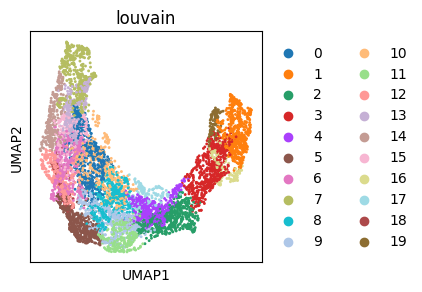

In [24]:
sc.tl.louvain(STA, random_state=0, key_added="louvain", resolution=1)
sc.pl.umap(STA, color='louvain')

### Slices before alignment

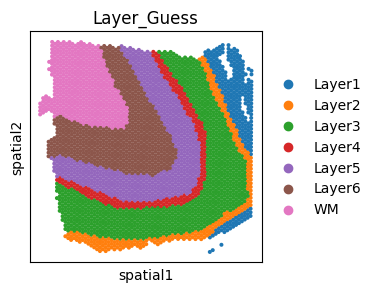

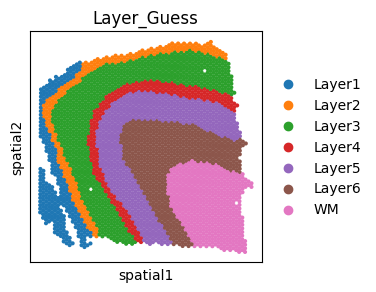

In [14]:
STA_73 = STA[STA.obs['batch_name']=='rep1']
STA_76 = STA[STA.obs['batch_name']=='rep2']

sc.pl.embedding(STA_73, basis='spatial', color='Layer_Guess')
sc.pl.embedding(STA_76, basis='spatial', color='Layer_Guess')

### Alignment call (same as CODA)
This call uses **the exact same API as CODA**. You can switch the global-alignment `mode` as needed:
- `mode="G1"` → **Mode I** (rotation/translation)
- `mode="G2"` → **Mode II** (uniform scaling + rotation/translation)
- `mode="G2+"` → **Mode III** (mild shear / anisotropic scaling)

`label_key="louvain"` is optional—any label column present in **both** `STA_73.obs` and `STA_76.obs` works.  
The aligned source coordinates are returned in `res["aligned"]` and saved to `STA_73.obsm["spatial_aligned"]`.


In [26]:
src_xy = STA_73.obsm['spatial']
dst_xy = STA_76.obsm['spatial']

res = align_points(
    src_xy, dst_xy,
    src_feat=None, dst_feat=None,     
    mode="G1", trim_fraction=0.10,
    if_labeled=True,
    label_key="louvain",
    src_adata=STA_73,
    dst_adata=STA_76
)
STA_73.obsm['spatial_aligned'] = res['aligned']

### Slices after alignment

- If needed, proceed with **common domain identification** and **local alignment (LDDMM)** — the steps are **identical to Tutorial 1** (same canvas size, mappings, and outputs).

- **Important**: STAligner provides a **low-dimensional embedding** (e.g., `obsm["STAligner"]`). This is **not suitable for spatial gene analysis (SCG/SDG)** because it does **not** retain per-gene expression.  
  For gene-level spatial analysis, use an integration that **preserves genes** (e.g., CODA preprocessing with `integrate="combat"` or `"none"` on the expression matrix) and run the analysis on **HVGs or the full gene set** as appropriate.


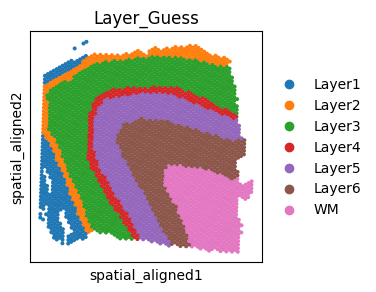

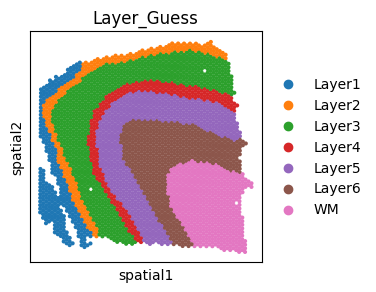

In [28]:
sc.pl.embedding(STA_73, basis='spatial_aligned', color='Layer_Guess')
sc.pl.embedding(STA_76, basis='spatial', color='Layer_Guess')